In [2]:
def plot_percentile_distributions(dfs, df_names, column_name, *, prefix_whitelist=[], prefix_blacklist=[], type_filter='LAST', figsize=(16, 4), percentiles=[30, 50, 70, 90], n_cols=4):
    """
    Plot percentile distributions for multiple dataframes.
    
    Args:
        dfs: List of dataframes to compare
        df_names: List of names for each dataframe
        column_name: Name of the column to analyze
        type_filter: Value to filter in the 'Type' column (default: 'FIRST')
        figsize: Base figure size (width, height) - height will be adjusted based on number of events
        percentiles: List of percentiles to mark on plots
        n_cols: Number of plots per row
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    assert len(dfs) == len(df_names), "Number of dataframes should match number of names"
    
    # Filter each dataframe
    filtered_dfs = [df[df['Type'] == type_filter] for df in dfs]
    
    # Get all unique events
    event_candidates = set()
    for df in filtered_dfs:
        event_candidates.update(df['Event'].unique())

    all_events = set()
    for event in event_candidates:
        if prefix_whitelist:
            for prefix in prefix_whitelist:
                if event.startswith(prefix):
                    all_events.add(event)
                    break
            continue
        elif prefix_blacklist:
            skip = False
            for prefix in prefix_blacklist:
                if event.startswith(prefix):
                    skip = True
                    break
            if skip:
                continue
        all_events.add(event)
    
    # Calculate average values for sorting
    event_sum = {}
    event_cnt = {}
    for event in all_events:
        # Get maximum average across all dataframes
        event_sum[event] = 0
        event_cnt[event] = 0
        for index, df in enumerate(filtered_dfs):
            event_data = df[df['Event'] == event][column_name]
            if index == 0:
                event_cnt[event] = len(event_data)
            if len(event_data) > 0:
                # Filter out p99 before calculating average
                p99 = np.percentile(event_data, 99)
                filtered_data = event_data[event_data <= p99]
                if index == 0:
                    event_sum[event] += filtered_data.sum()
    
    # Sort events by average value
    sorted_events = sorted(all_events, key=lambda x: event_sum[x], reverse=True)
    
    # Calculate grid dimensions
    n_events = len(sorted_events)
    n_rows = (n_events + n_cols - 1) // n_cols
    
    # Create subplot grid
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(figsize[0], figsize[1]*n_rows))
    axes = axes.flatten()
    
    # Colors for different dataframes
    colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray']

    # For each event, create a subplot
    for idx, event in enumerate(sorted_events):
        # Plot data from each dataframe
        for df_idx, (df, name) in enumerate(zip(filtered_dfs, df_names)):
            event_data = df[df['Event'] == event][column_name]
            
            if len(event_data) > 0:
                # Filter out p99
                p99 = np.percentile(event_data, 99)
                filtered_data = event_data[event_data <= p99]
                
                sorted_samples = np.sort(filtered_data.values)
                # Calculate percentiles for x-axis
                percentile_indices = np.linspace(0, 100, len(sorted_samples))
                
                # Plot the line
                axes[idx].plot(percentile_indices, sorted_samples, 
                             color=colors[df_idx % len(colors)],
                             label=name)
                
                # Add percentile lines (only for the first dataset)
                if df_idx == 0:
                    for p in percentiles:
                        axes[idx].axvline(p, color='gray', linestyle='--', alpha=0.3)
                        axes[idx].text(p, axes[idx].get_ylim()[0], f'{p}%', 
                                     rotation=90, verticalalignment='bottom')
        
        # Add title with average value
        sum_value = event_sum[event] / 1000000
        cnt_value = event_cnt[event]
        axes[idx].set_title(f"{event}\nsum: {sum_value:,.2f}kk cnt: {cnt_value}")
        axes[idx].grid(True)
        axes[idx].legend()
        
        # Remove x-axis numbers but keep the grid
        axes[idx].set_xticks([])
        # Add x-axis label
        axes[idx].set_xlabel('Percentile')
    
    # Remove empty subplots if any
    for idx in range(n_events, len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()

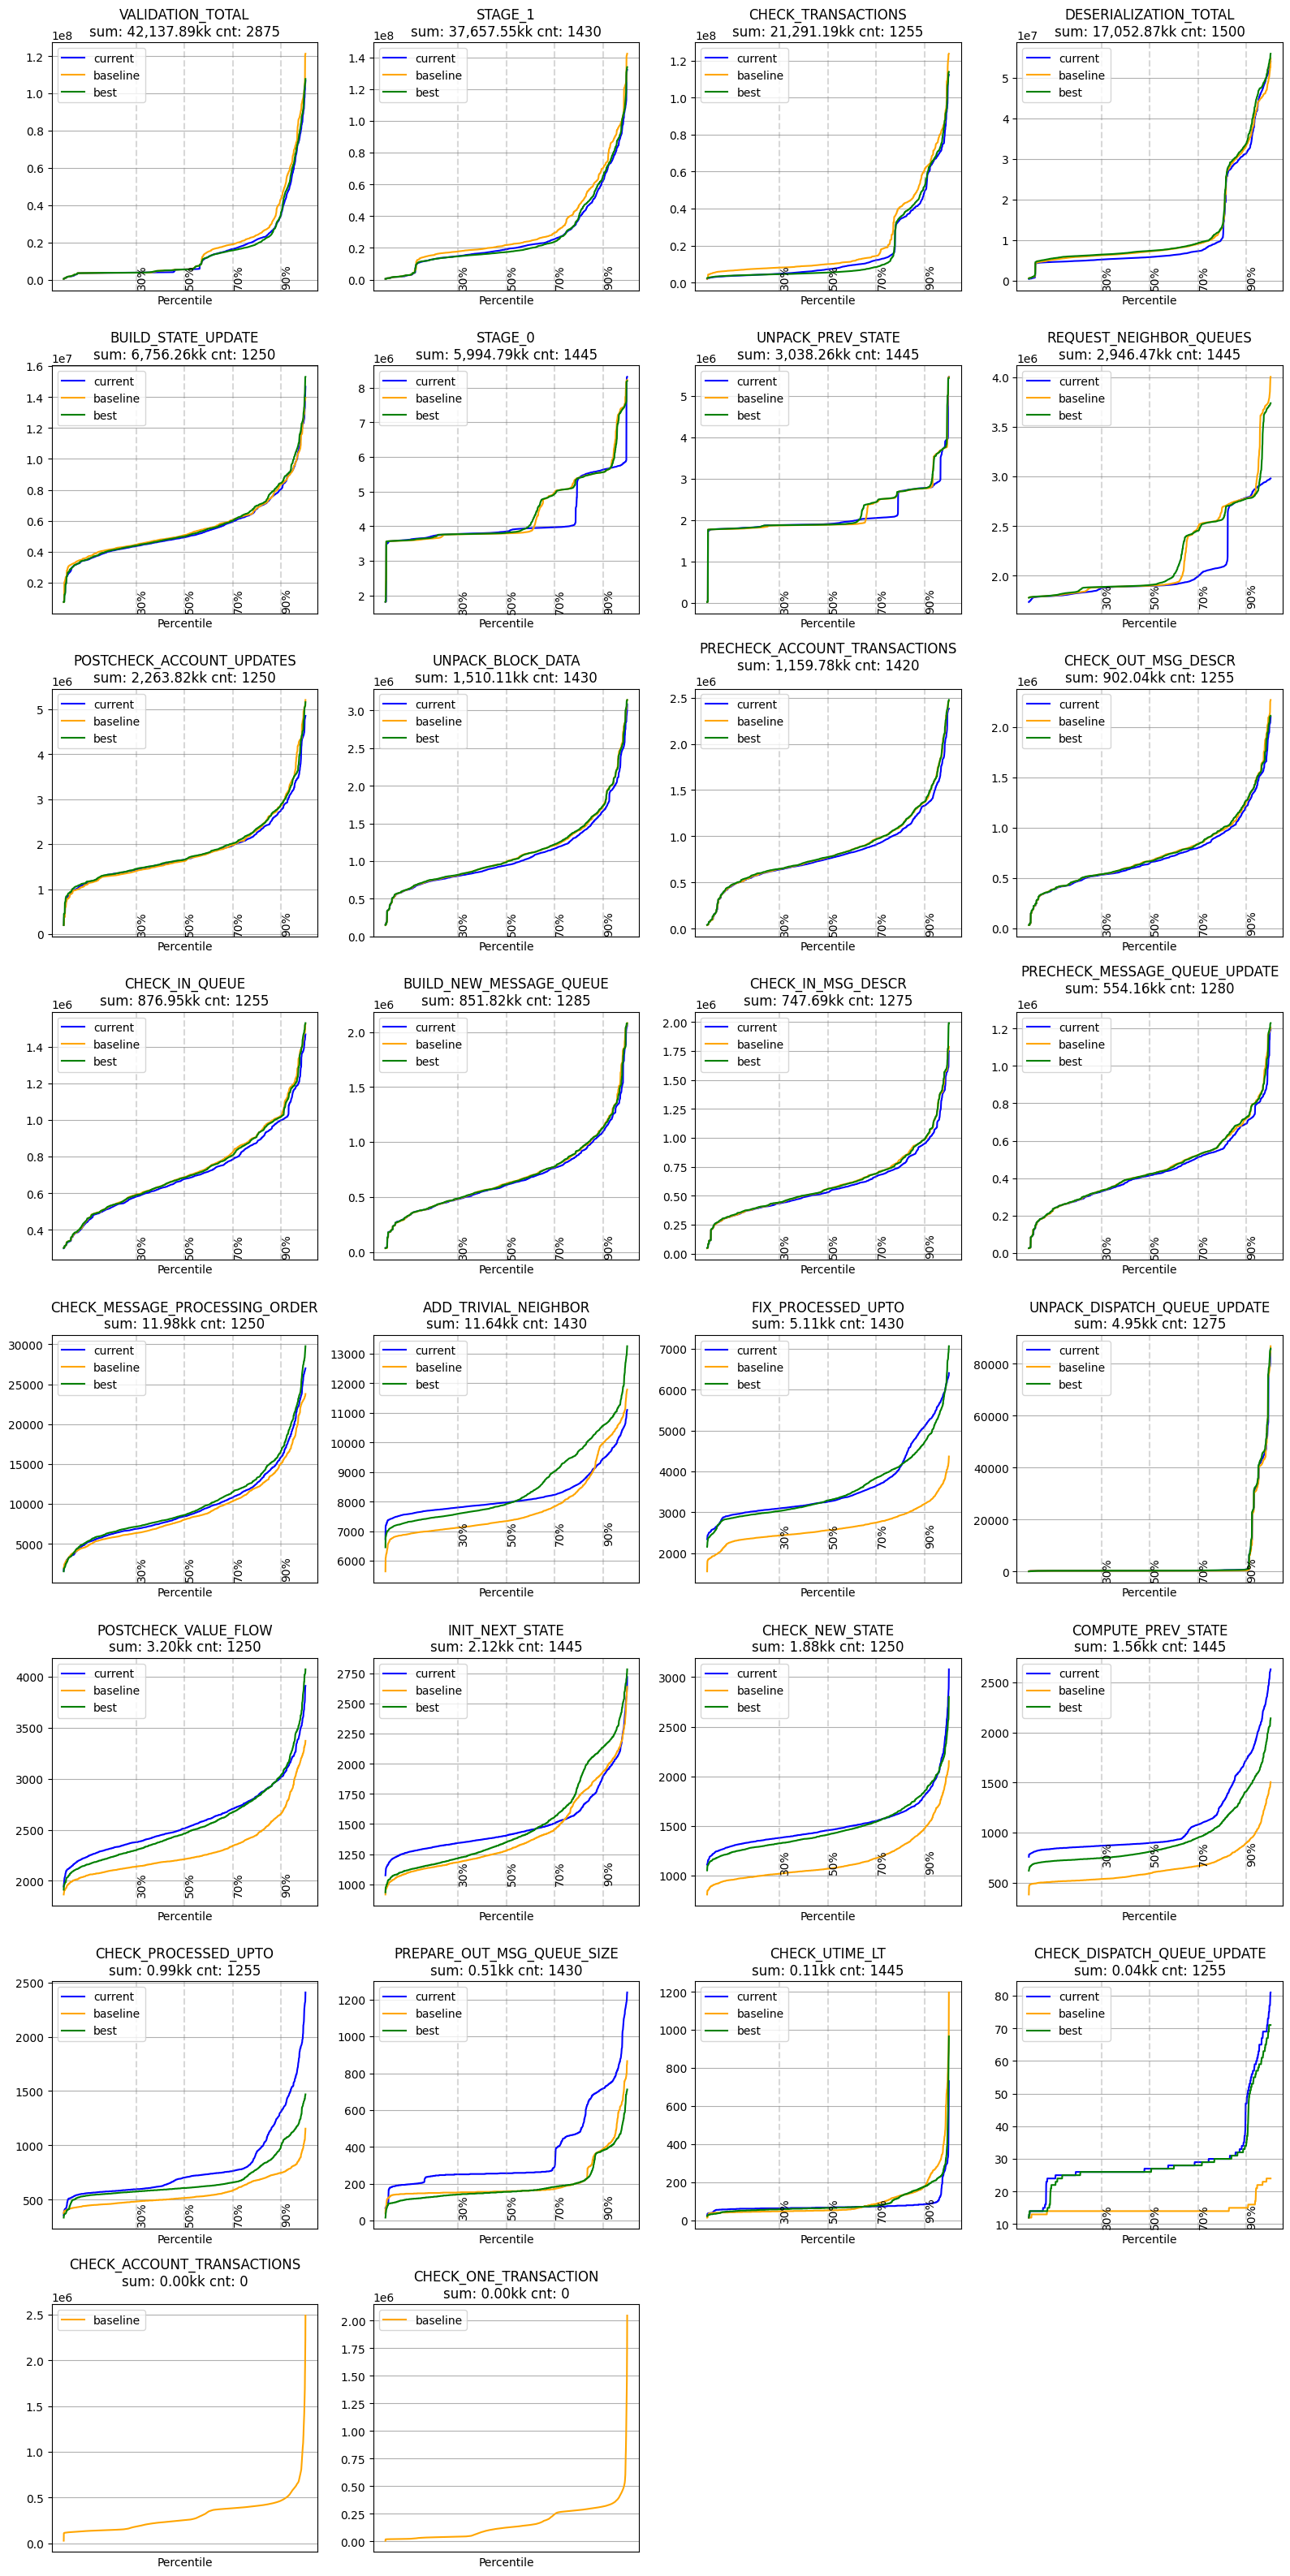

In [3]:
plot_percentile_distributions(
    dfs=[df, baseline_df, best_df],
    df_names=['current', 'baseline', 'best'],
    column_name='TSC',
    prefix_blacklist=["XX_"]
)

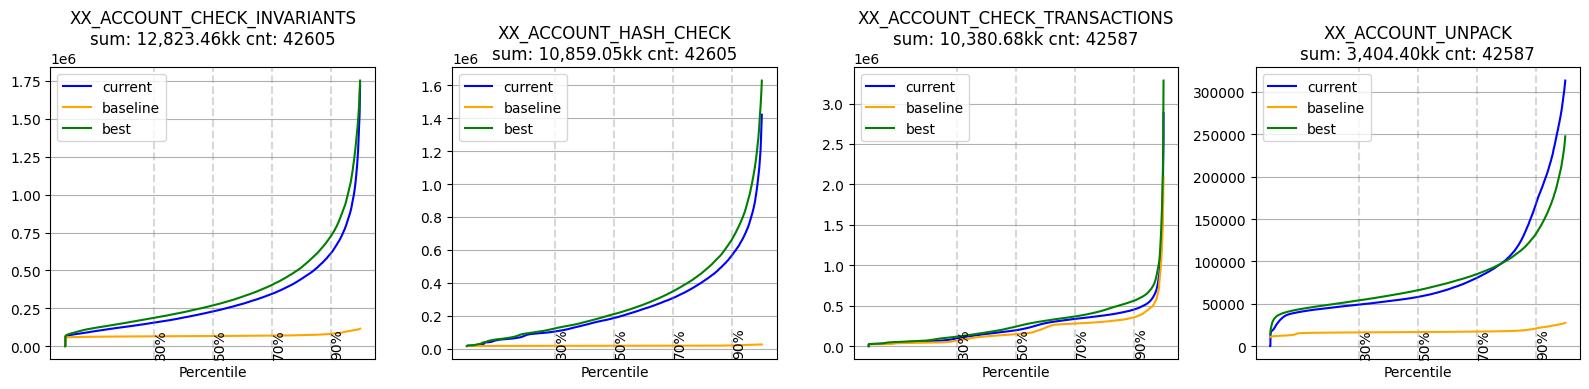

In [4]:
plot_percentile_distributions(
    dfs=[df, baseline_df, best_df],
    df_names=['current', 'baseline', 'best'],
    column_name='TSC',
    prefix_whitelist=['XX_ACCOUNT_']
)

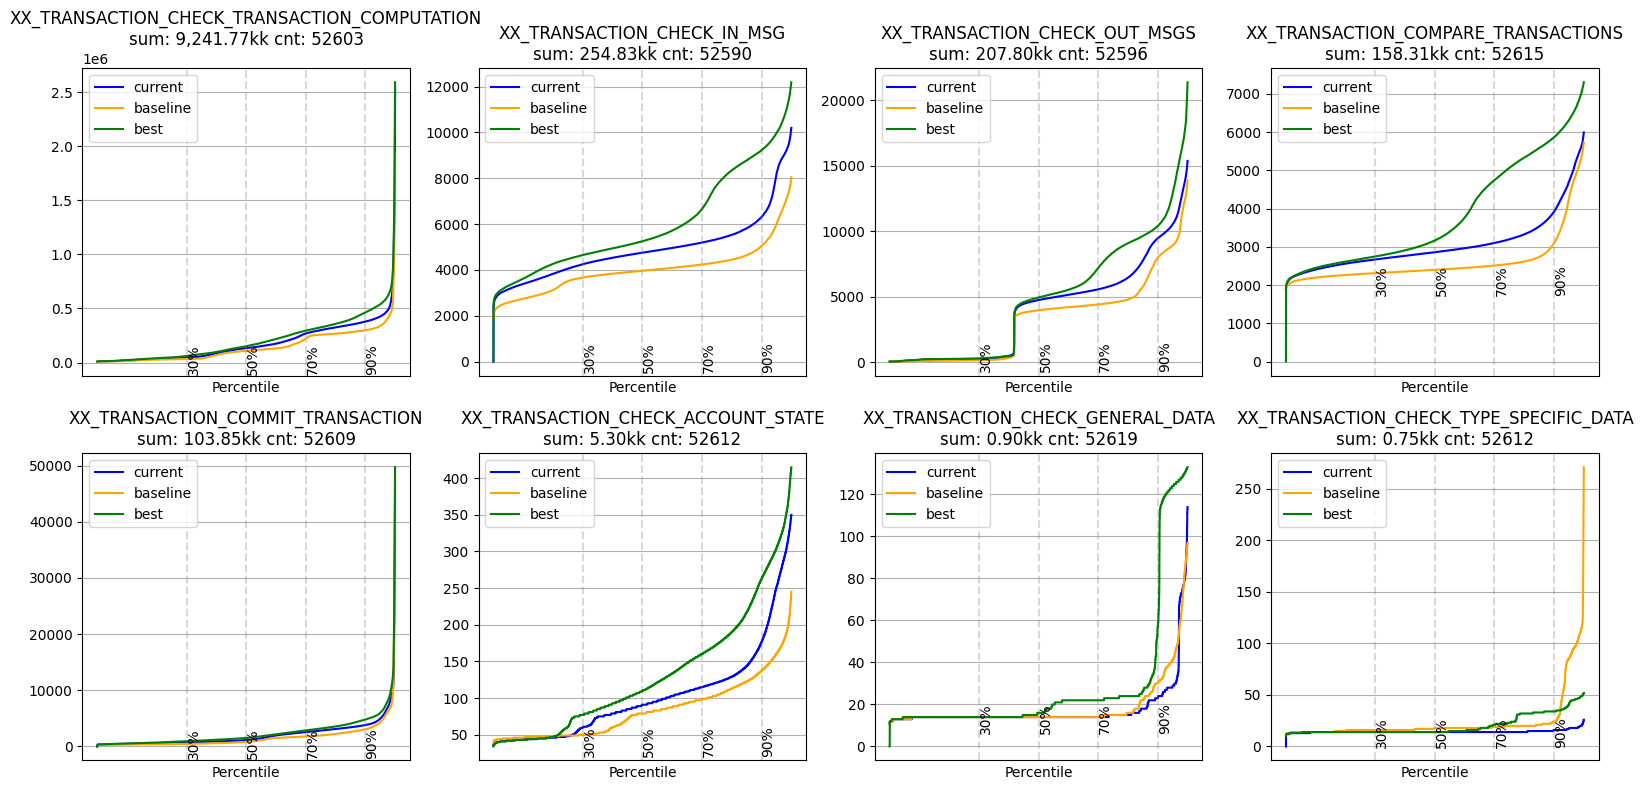

In [5]:
plot_percentile_distributions(
    dfs=[df, baseline_df, best_df],
    df_names=['current', 'baseline', 'best'],
    column_name='TSC',
    prefix_whitelist=['XX_TRANSACTION_']
)

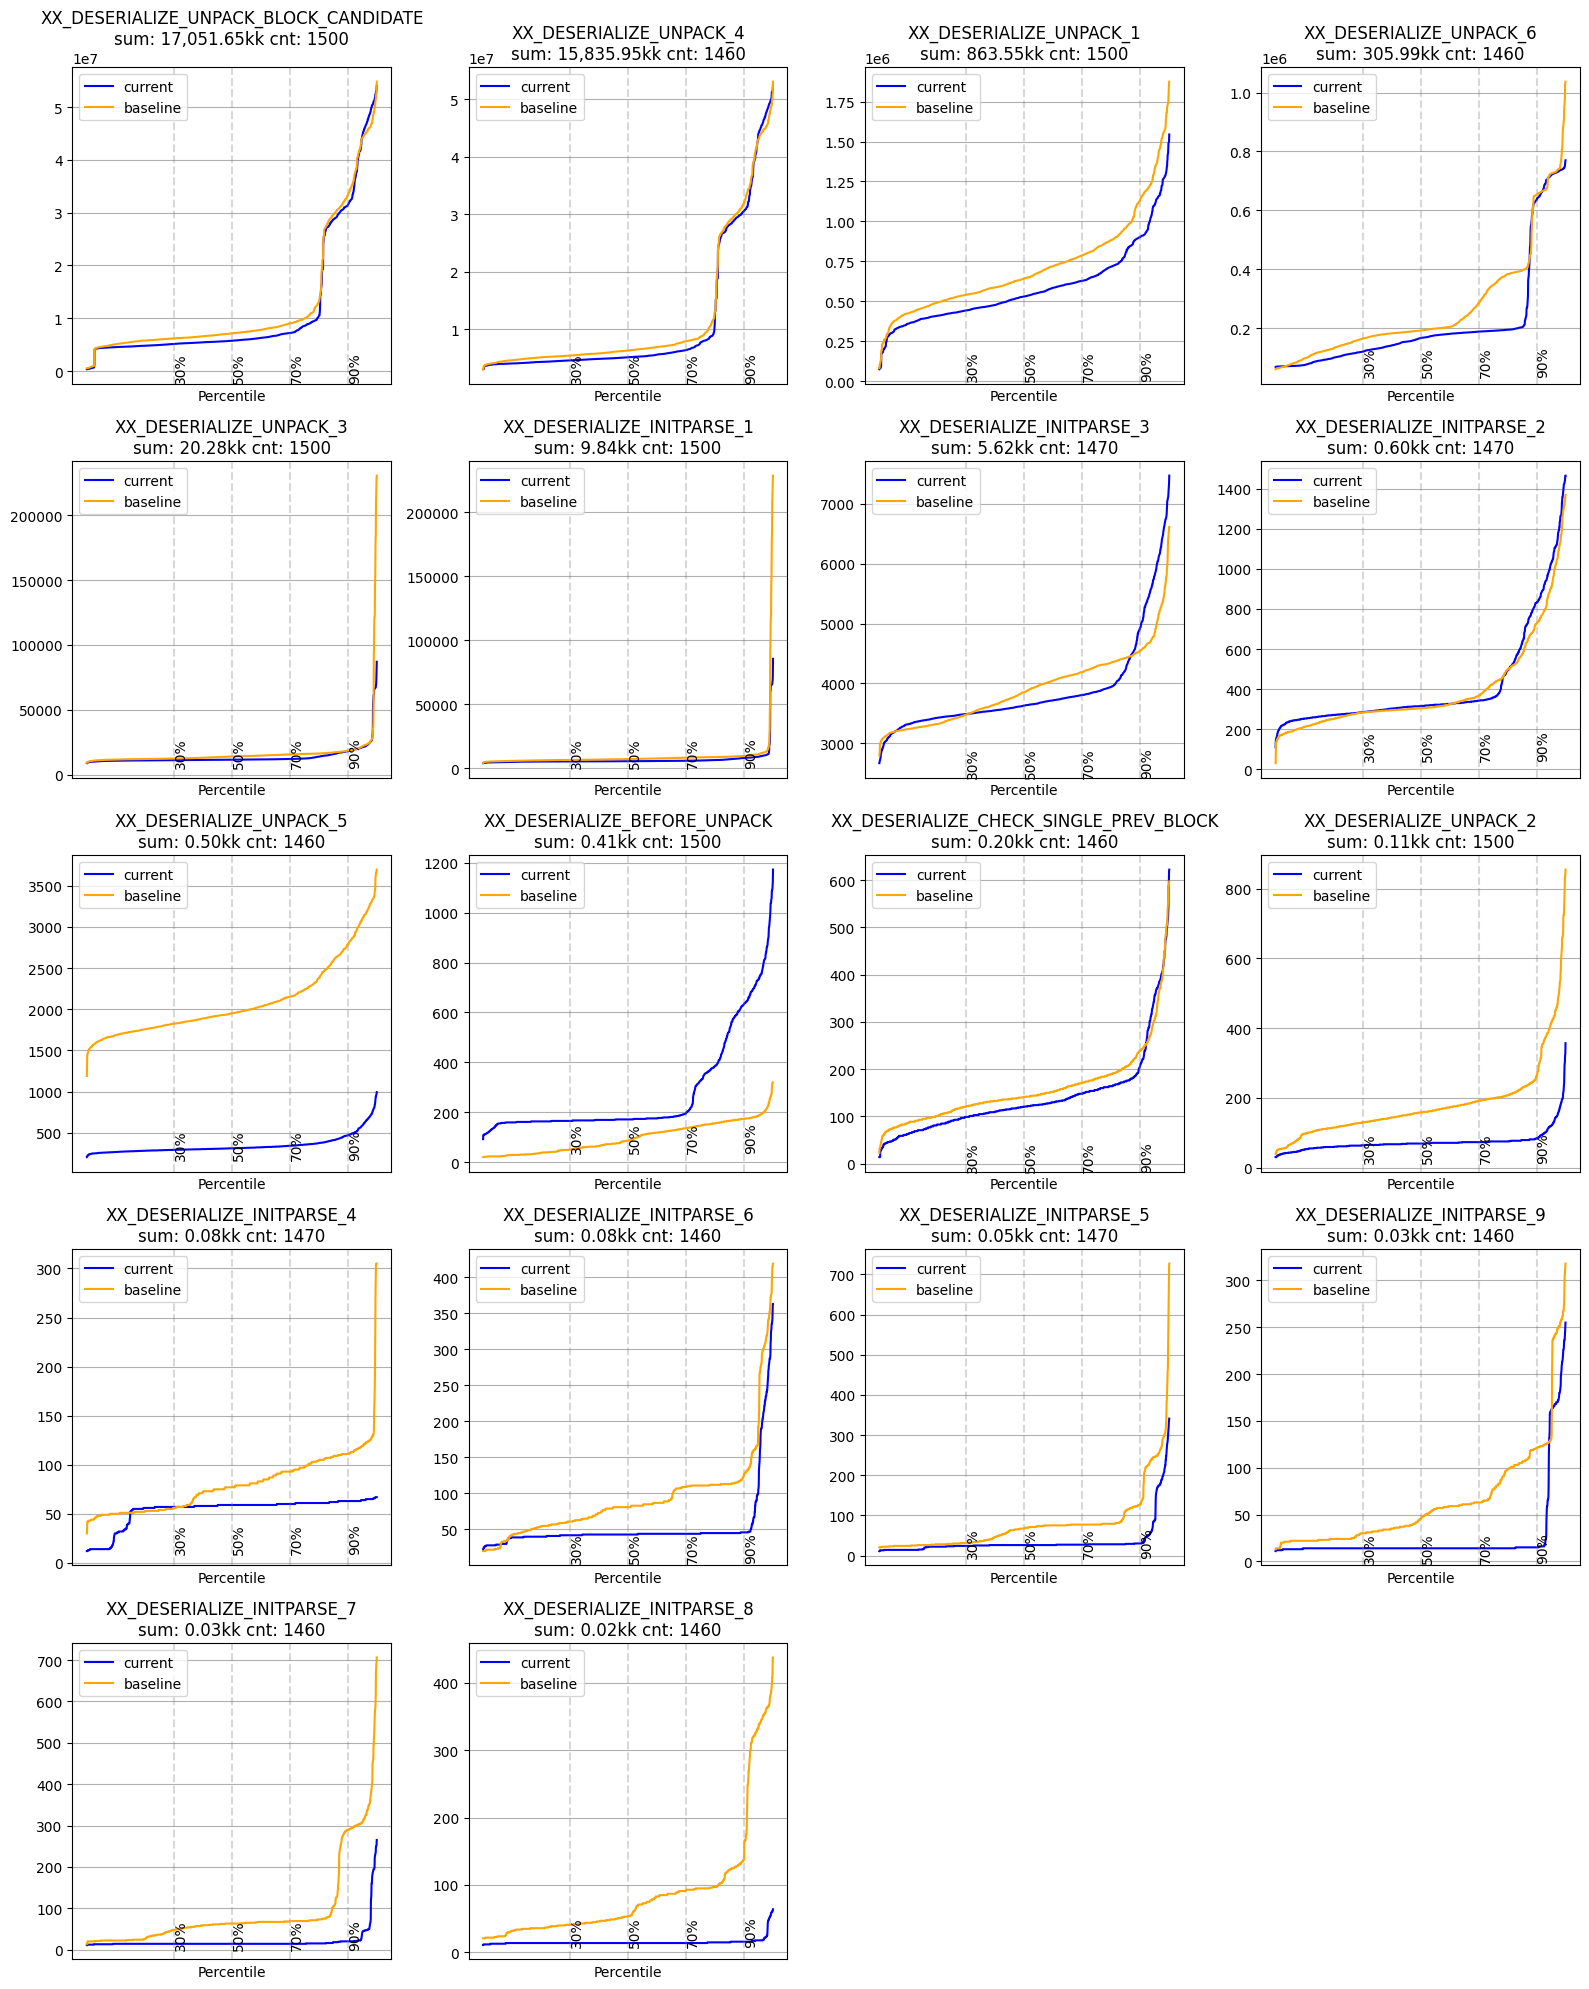

In [6]:
plot_percentile_distributions(
    dfs=[df, baseline_df, best_df],
    df_names=['current', 'baseline', 'best'],
    column_name='TSC',
    prefix_whitelist=['XX_DESERIALIZE_']
)

In [7]:
def plot_total_sums(dfs, df_names, column_name, type_filter='FIRST', figsize=(16, 6), n_cols=1):
   """
   Plot bar chart showing total sum of samples for each event across multiple dataframes.
   
   Args:
       dfs: List of dataframes to compare
       df_names: List of names for each dataframe
       column_name: Name of the column to analyze
       type_filter: Value to filter in the 'Type' column (default: 'FIRST')
       figsize: Figure size (width, height)
       n_cols: Number of columns in the plot (1 for vertical bars, can be increased for horizontal layout)
   """
   import matplotlib.pyplot as plt
   import numpy as np
   
   assert len(dfs) == len(df_names), "Number of dataframes should match number of names"
   
   # Filter each dataframe
   filtered_dfs = [df[df['Type'] == type_filter] for df in dfs]
   
   # Get all unique events
   all_events = set()
   for df in filtered_dfs:
       all_events.update(df['Event'].unique())
   
   # Calculate sums for each event and dataframe
   event_sums = {}
   for event in all_events:
       sums = []
       for df in filtered_dfs:
           event_data = df[df['Event'] == event][column_name]
           if len(event_data) > 0:
               # Filter out p99
               p99 = np.percentile(event_data, 99)
               filtered_data = event_data[event_data <= p99]
               sums.append(filtered_data.sum())
           else:
               sums.append(0)
       event_sums[event] = max(sums)  # For sorting purposes
   
   # Sort events by total sum
   sorted_events = sorted(all_events, key=lambda x: event_sums[x], reverse=True)
   
   # Set up the plot
   n_events = len(sorted_events)
   bar_width = 0.8 / len(dfs)  # Width of each bar
   
   # Colors for different dataframes
   colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray']
   
   # Create figure
   plt.figure(figsize=figsize)
   
   # Create bars for each dataframe
   for df_idx, (df, name) in enumerate(zip(filtered_dfs, df_names)):
       positions = np.arange(len(sorted_events))
       values = []
       
       for event in sorted_events:
           event_data = df[df['Event'] == event][column_name]
           if len(event_data) > 0:
               # Filter out p99
               p99 = np.percentile(event_data, 99)
               filtered_data = event_data[event_data <= p99]
               values.append(filtered_data.sum())
           else:
               values.append(0)
       
       # Calculate offset for grouped bars
       offset = bar_width * (df_idx - (len(dfs)-1)/2)
       
       plt.bar(positions + offset, 
              values,
              bar_width,
              label=name,
              color=colors[df_idx % len(colors)])
   
   # Customize the plot
   plt.title(f'Total {column_name} by Event ({type_filter} type) [p99 filtered]')
   plt.xlabel('Event')
   plt.ylabel(f'Total {column_name}')
   plt.xticks(range(len(sorted_events)), sorted_events, rotation=45, ha='right')
   plt.grid(True, axis='y')
   plt.legend()
   
   # Add value labels on top of bars
   for df_idx, df in enumerate(filtered_dfs):
       positions = np.arange(len(sorted_events))
       for i, event in enumerate(sorted_events):
           event_data = df[df['Event'] == event][column_name]
           if len(event_data) > 0:
               # Filter out p99
               p99 = np.percentile(event_data, 99)
               filtered_data = event_data[event_data <= p99]
               value = filtered_data.sum()
           else:
               value = 0
               
           if value > 0:  # Only add label if there's a value
               offset = bar_width * (df_idx - (len(dfs)-1)/2)
               plt.text(i + offset, value, 
                       f'{value:,.0f}', 
                       ha='center', va='bottom', 
                       rotation=90)
   
   plt.tight_layout()
   plt.show()

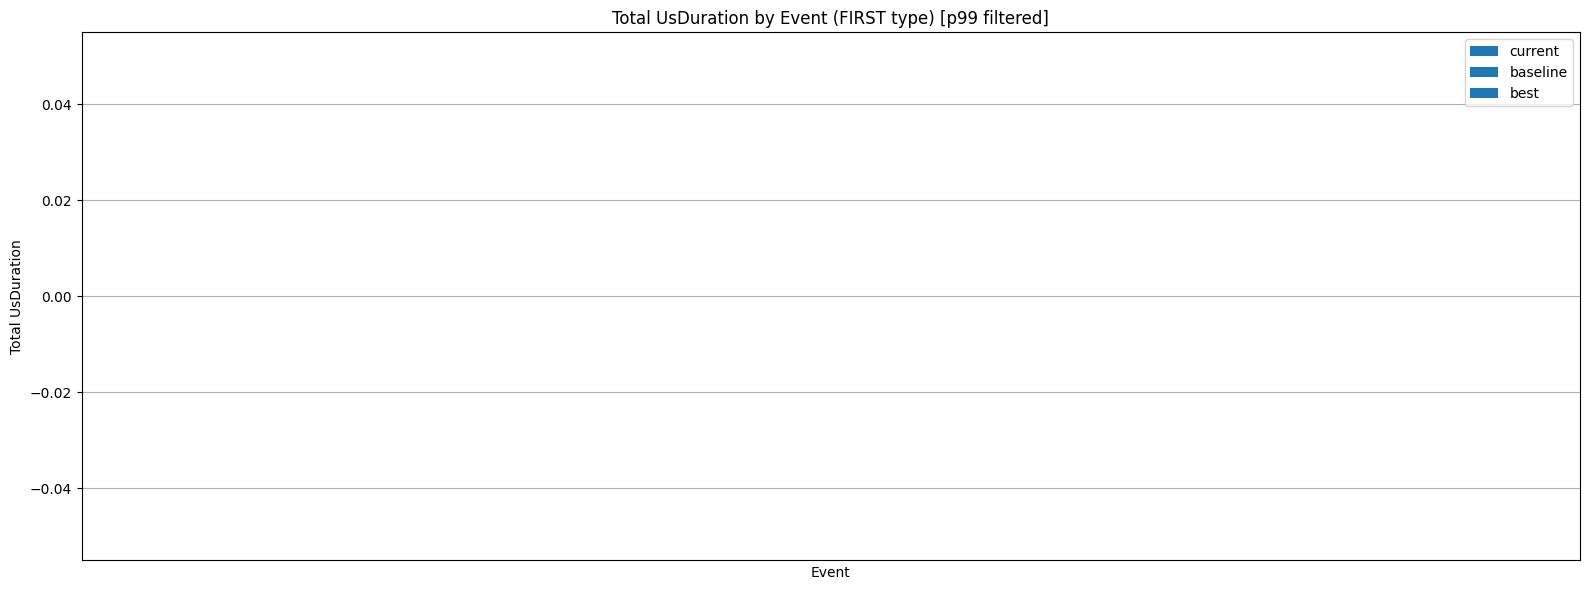

In [8]:
plot_total_sums(
    dfs=[df, baseline_df, best_df],
    df_names=['current', 'baseline', 'best'],
    column_name='UsDuration'
)